In [71]:
import pandas as pd
import numpy as np
import seaborn as snb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.graph_objects as go
import plotly.offline as py
import warnings
warnings.filterwarnings('ignore')

In [51]:
data= pd.read_csv("C:/Users/akrit/Downloads/data.csv")

In [52]:
data.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN


In [53]:
frame= pd.DataFrame({"null value":data.isnull().sum(),"percentage of  null value":(data.isnull().sum())/(data.shape[0])*100})
frame

,null value,percentage of null value
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


In [54]:


trace = go.Bar(
    x=frame.index,
    y=frame['null value'],
    opacity=0.8,
    marker=dict(
        color='lightgrey',
        line=dict(color='#000000', width=1.5)
    )
)

layout = dict(title='Missing Value')

fig = dict(data=[trace], layout=layout)

py.plot(fig)


# msno.bar(data)
# plt.show()

'temp-plot.html'

In [46]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [91]:

# data.drop(['Unnamed: 32'],inplace=True,axis=1)
# data.drop(['id'],inplace=True,axis=1)


In [57]:
mapp={'M':1,'B':0}
data['diagnosis']=data['diagnosis'].map(mapp)

In [77]:
data['radius_mean'].max()

28.11

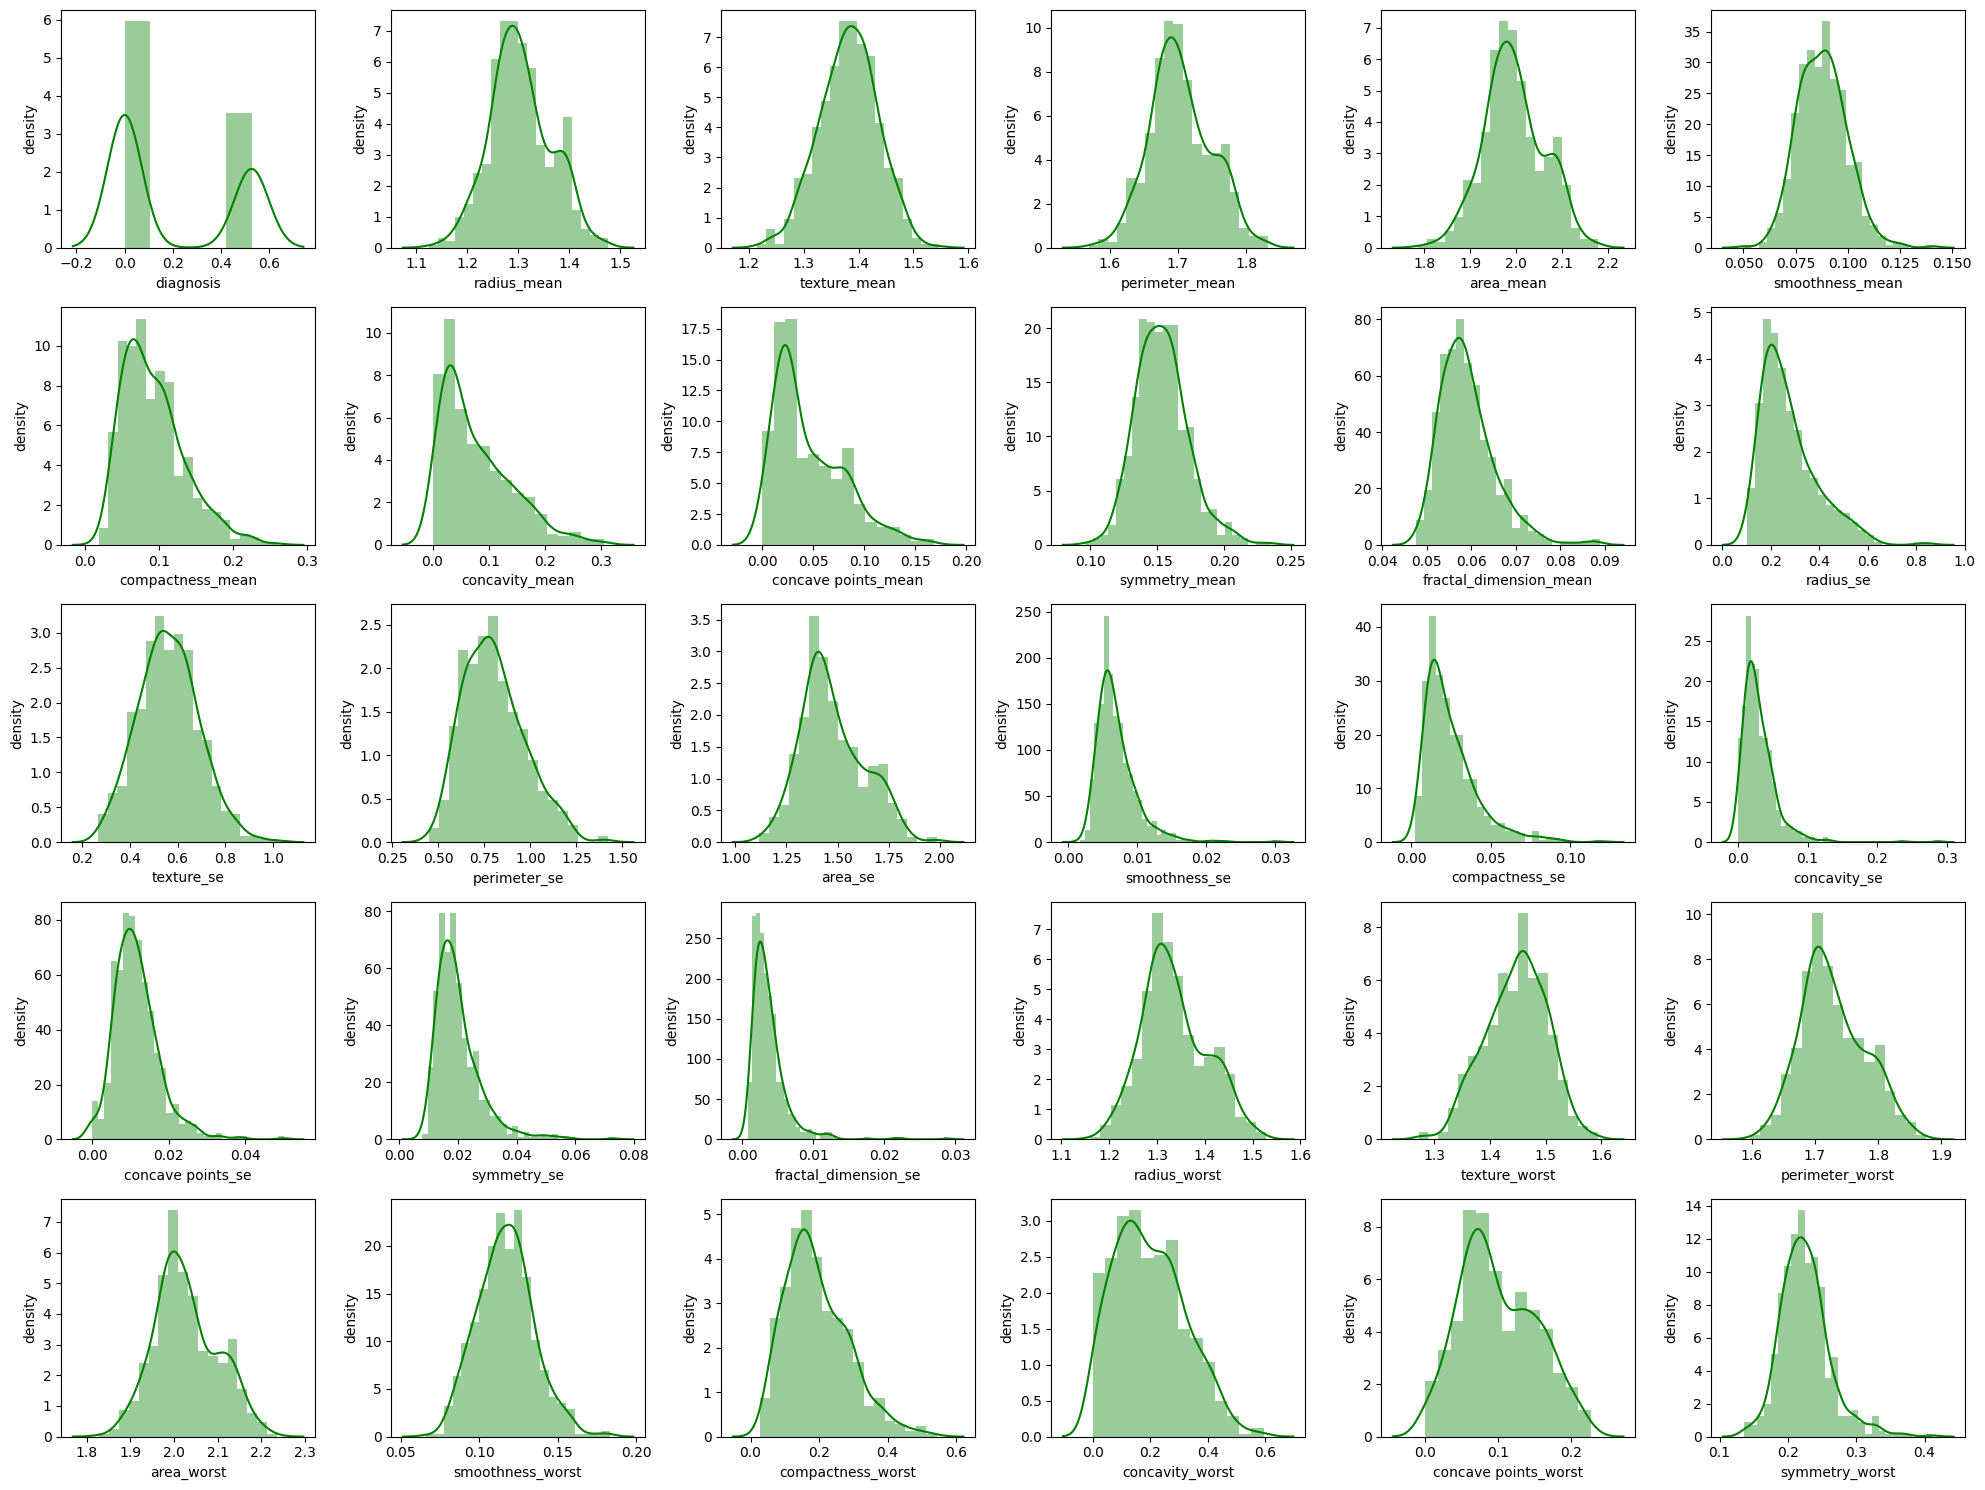

In [92]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.distplot(data[columns],ax=ax,color='green')
        # sns.histplot(data[columns],kde=True,ax=ax,color='green')
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

In [93]:
for col in data:
    data[col]=np.log(data[col]+1)

In [94]:
data.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.423036,0.863807,0.803391,1.015619,1.121057,0.100813,0.198131,0.209489,0.120979,0.179062,0.070489,0.440593,0.403811,0.780204,1.029022,0.006338,0.045704,0.049754,0.015502,0.028742,0.006136,0.896995,0.860001,1.039693,1.148362,0.131059,0.345172,0.357832,0.191765,0.278389,0.101176
1,0.423036,0.877119,0.862558,1.020456,1.132368,0.075294,0.070433,0.076997,0.063554,0.143264,0.052267,0.307856,0.363598,0.646434,0.982528,0.005184,0.012829,0.018097,0.013137,0.013607,0.003513,0.895570,0.889491,1.031049,1.147192,0.104713,0.146640,0.178896,0.146267,0.196787,0.078660
2,0.423036,0.872832,0.880273,1.019114,1.128511,0.094346,0.129546,0.153273,0.107641,0.158983,0.055080,0.366602,0.376880,0.693479,0.998627,0.006094,0.037803,0.036249,0.019966,0.021768,0.004540,0.890131,0.897536,1.028676,1.142146,0.119140,0.264616,0.274713,0.179670,0.238100,0.077532


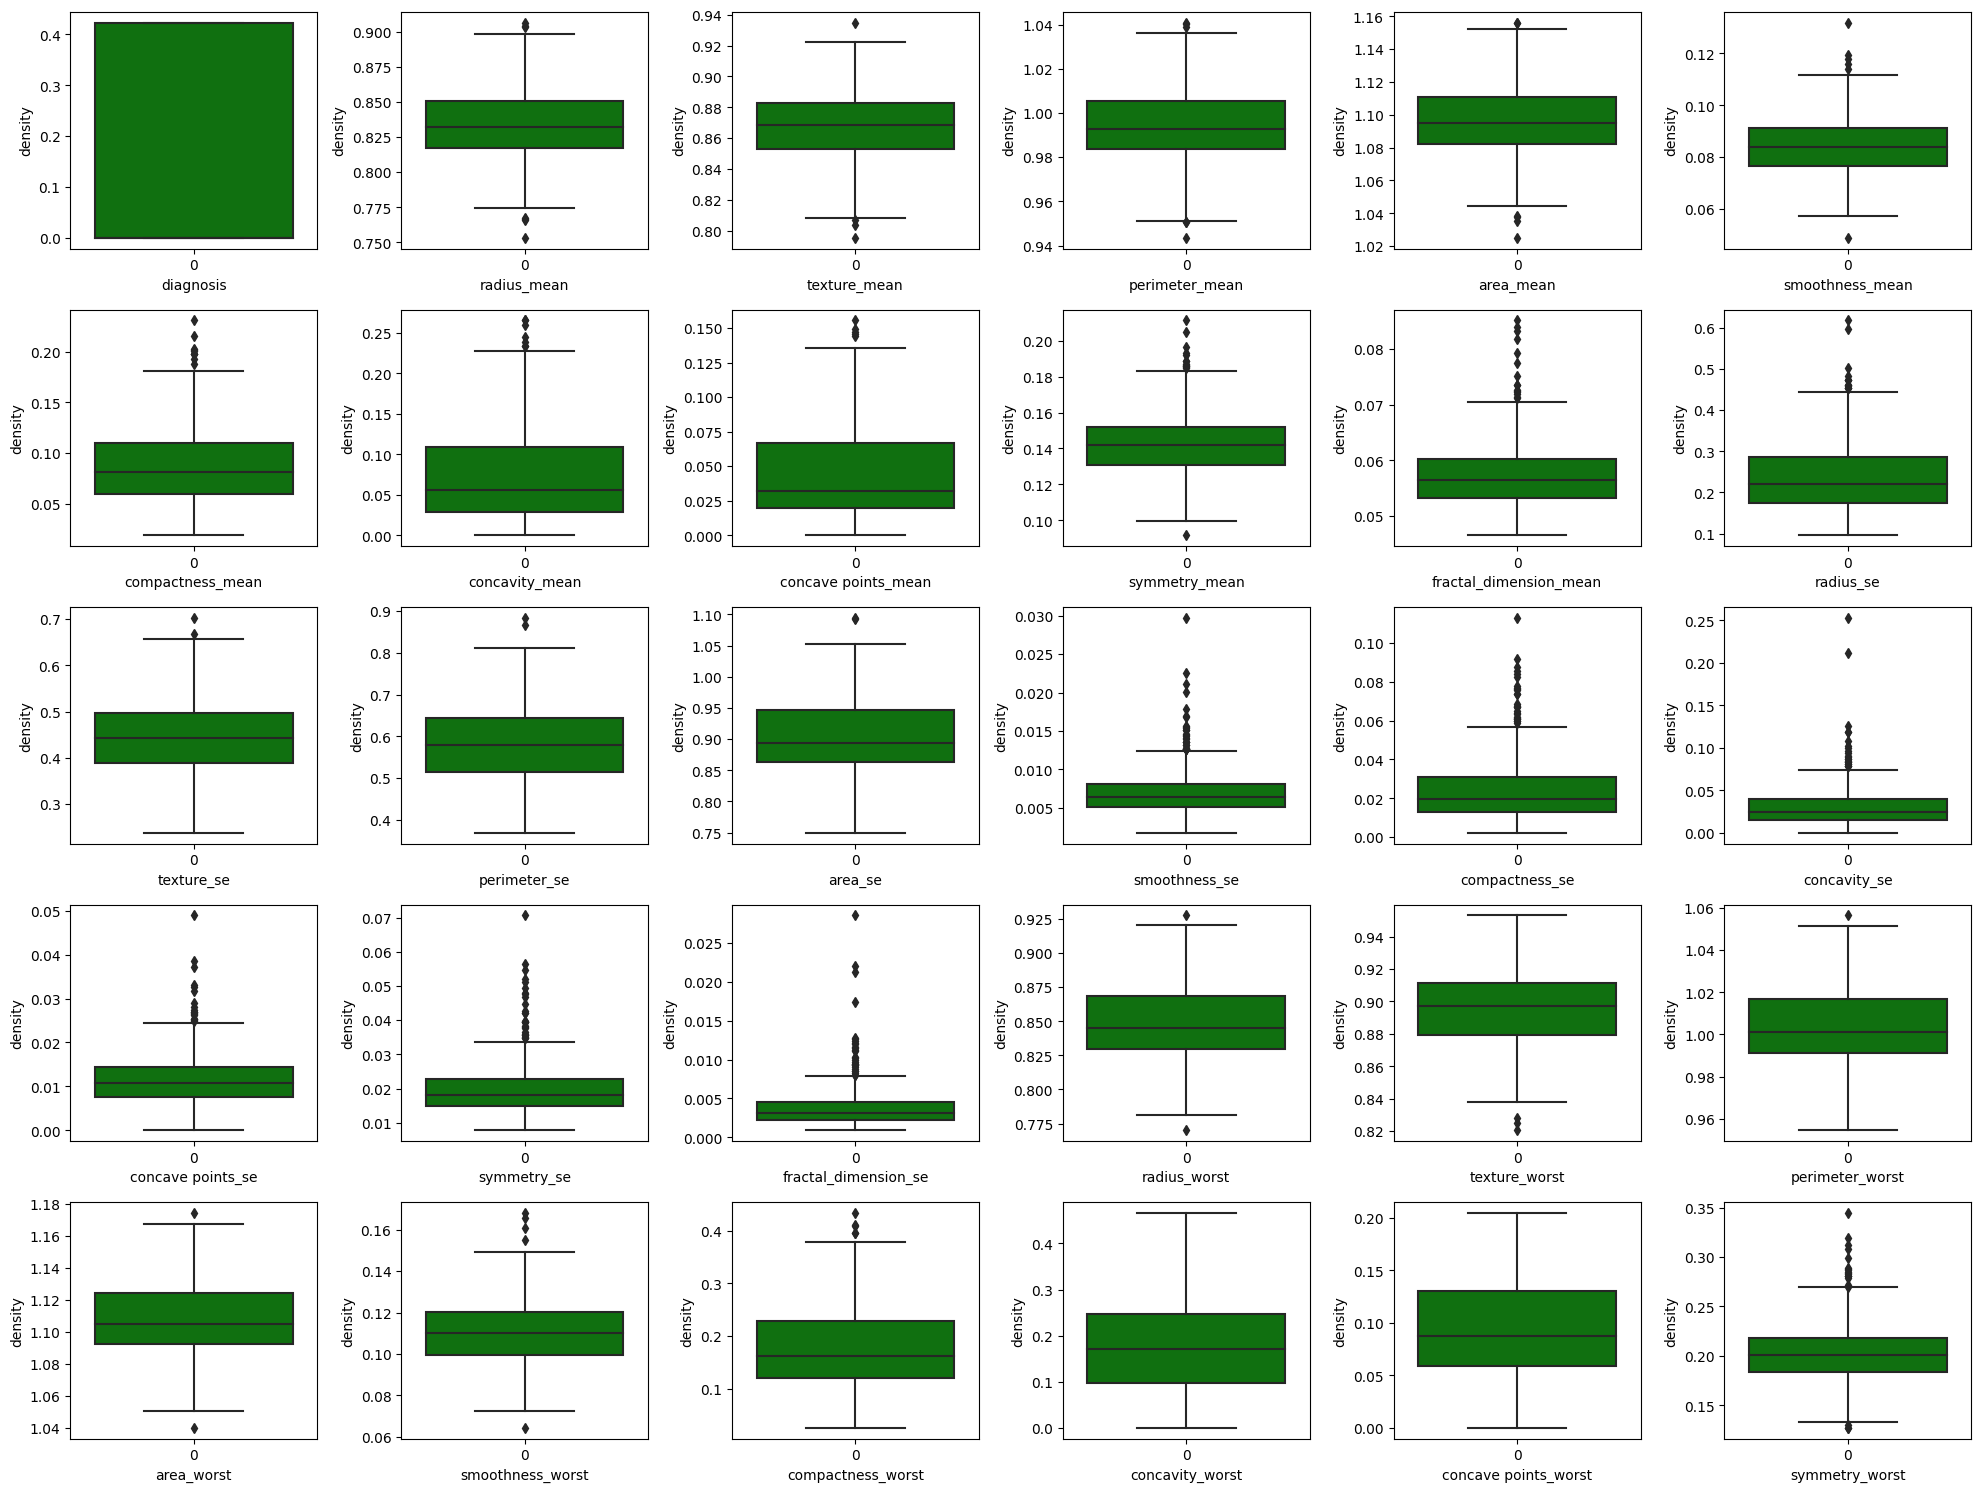

In [95]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.boxplot(data[columns],ax=ax,color='green')
      
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

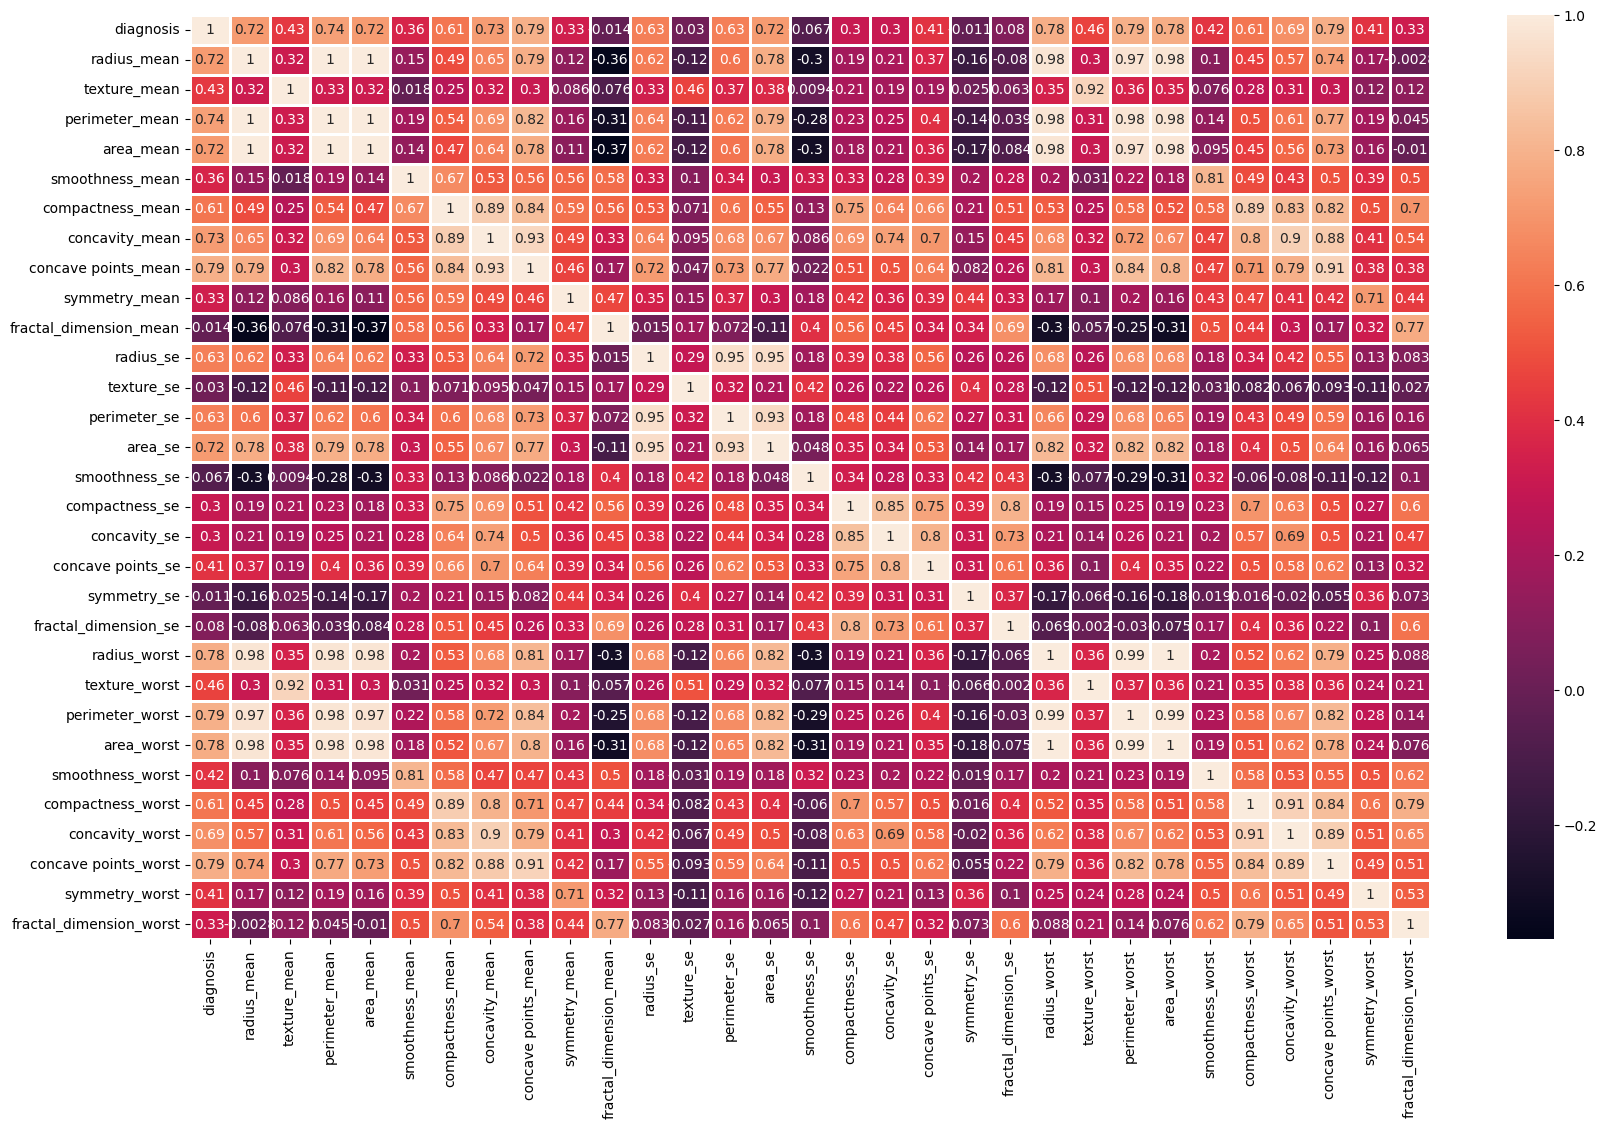

In [99]:
plt.figure(figsize = (20, 12))
corr= data.corr()
sns.heatmap(corr, linewidths = 1, annot = True)
plt.show()